In [ ]:
import torch

# Check PyTorch version
print("PyTorch version:", torch.__version__)

# Check if CUDA (GPU support) is available
print("CUDA available:", torch.cuda.is_available())

# If CUDA is available, print details
if torch.cuda.is_available():
    print("Number of GPUs:", torch.cuda.device_count())
    print("Current device:", torch.cuda.current_device())
    print("GPU name:", torch.cuda.get_device_name(torch.cuda.current_device()))
    print("CUDA version:", torch.version.cuda)
else:
    print("No GPU detected.")


The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.
PyTorch version: 2.9.0+cu126
CUDA available: True
Number of GPUs: 4
Current device: 0
GPU name: NVIDIA GeForce GTX TITAN X
CUDA version: 12.6


In [2]:
from ICL_toymodel import *


In [3]:
import torch

# Create a config (you can shorten seq_len for faster test)
cfg = ICLConfig(
    n_channels=54,
    seq_len=4096,      # shorter for test
    ch_chunk=8,
    t_chunk=1024,
    tfm_checkpoint=False
)

# Instantiate one of the models (PR, PRC, or PRCE)
model = PRCE(cfg)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()

# Dummy waveform batch: (batch=2, channels=54, samples=4096)
x = torch.randn(2, cfg.n_channels, cfg.seq_len, device=device)

# Run a forward pass
with torch.no_grad():
    out = model(x)

# Show output shapes
for k, v in out.items():
    print(f"{k}: shape={tuple(v.shape)} dtype={v.dtype}")


/home/dwong/anaconda3/envs/icl/lib/python3.12/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


pos: shape=(2, 3) dtype=torch.float32
logit: shape=(2, 1) dtype=torch.float32
energy: shape=(2, 1) dtype=torch.float32


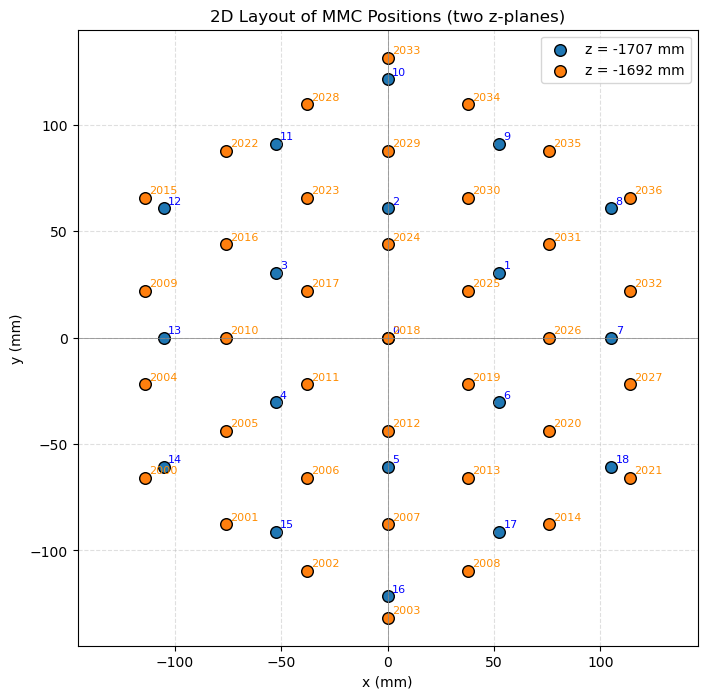

In [3]:
import matplotlib.pyplot as plt
import numpy as np
# -------------------
# Positions for z = -1707 (IDs 0–18)
# -------------------
positions_1707 = {
    0: (0.0, 0.0),
    1: (52.61603, 30.37788),
    2: (0.0, 60.75575),
    3: (-52.61603, 30.37788),
    4: (-52.61603, -30.37788),
    5: (0.0, -60.75575),
    6: (52.61603, -30.37788),
    7: (105.23205, 0.0),
    8: (105.23205, 60.75575),
    9: (52.61603, 91.13363),
    10: (0.0, 121.51151),
    11: (-52.61603, 91.13363),
    12: (-105.23205, 60.75575),
    13: (-105.23205, 0.0),
    14: (-105.23205, -60.75575),
    15: (-52.61603, -91.13363),
    16: (0.0, -121.51151),
    17: (52.61603, -91.13363),
    18: (105.23205, -60.75575),
}

# -------------------
# Positions for z = -1692 (IDs 2000–2036)
# -------------------
positions_1692 = {
    2000: (-113.97308, -65.80239),
    2001: (-75.98205, -87.73651),
    2002: (-37.99103, -109.67064),
    2003: (0.0, -131.60477),
    2004: (-113.97308, -21.93413),
    2005: (-75.98205, -43.86826),
    2006: (-37.99103, -65.80239),
    2007: (0.0, -87.73651),
    2008: (37.99103, -109.67064),
    2009: (-113.97308, 21.93413),
    2010: (-75.98205, 0.0),
    2011: (-37.99103, -21.93413),
    2012: (0.0, -43.86826),
    2013: (37.99103, -65.80239),
    2014: (75.98205, -87.73651),
    2015: (-113.97308, 65.80239),
    2016: (-75.98205, 43.86826),
    2017: (-37.99103, 21.93413),
    2018: (0.0, 0.0),
    2019: (37.99103, -21.93413),
    2020: (75.98205, -43.86826),
    2021: (113.97308, -65.80239),
    2022: (-75.98205, 87.73651),
    2023: (-37.99103, 65.80239),
    2024: (0.0, 43.86826),
    2025: (37.99103, 21.93413),
    2026: (75.98205, 0.0),
    2027: (113.97308, -21.93413),
    2028: (-37.99103, 109.67064),
    2029: (0.0, 87.73651),
    2030: (37.99103, 65.80239),
    2031: (75.98205, 43.86826),
    2032: (113.97308, 21.93413),
    2033: (0.0, 131.60477),
    2034: (37.99103, 109.67064),
    2035: (75.98205, 87.73651),
    2036: (113.97308, 65.80239),
}

# -------------------
# Extract coordinates
# -------------------
def extract_xy(d):
    ids, xs, ys = zip(*[(i, x, y) for i, (x, y) in d.items()])
    return ids, np.array(xs), np.array(ys)

ids1, xs1, ys1 = extract_xy(positions_1707)
ids2, xs2, ys2 = extract_xy(positions_1692)

# -------------------
# Plot
# -------------------
plt.figure(figsize=(8, 8))
plt.scatter(xs1, ys1, c="tab:blue", s=70, edgecolor="black", label="z = -1707 mm")
plt.scatter(xs2, ys2, c="tab:orange", s=70, edgecolor="black", label="z = -1692 mm")

# Annotate a few points
for i, x, y in zip(ids1, xs1, ys1):
    plt.text(x + 2, y + 2, str(i), fontsize=8, color="blue")
for i, x, y in zip(ids2, xs2, ys2):
    plt.text(x + 2, y + 2, str(i), fontsize=8, color="darkorange")

plt.axhline(0, color="gray", lw=0.5)
plt.axvline(0, color="gray", lw=0.5)
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.title("2D Layout of MMC Positions (two z-planes)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.4)
plt.axis("equal")
plt.show()


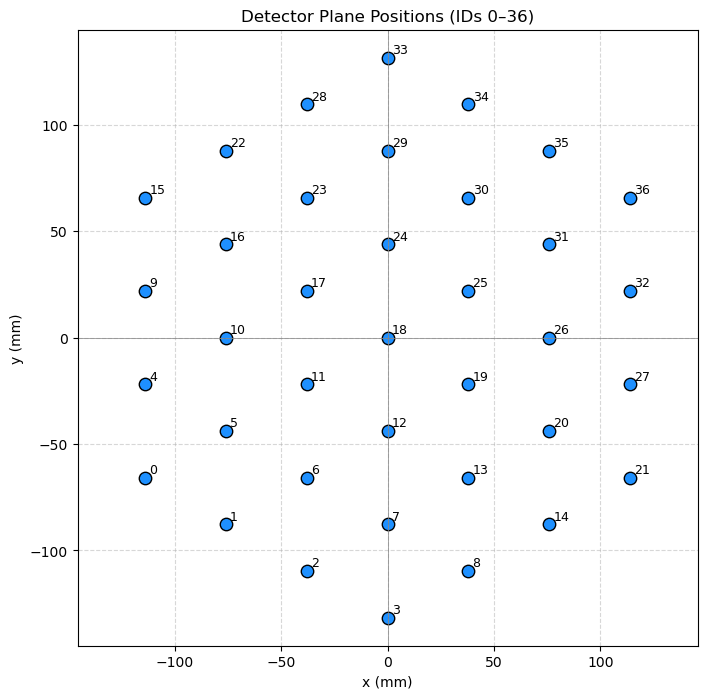

In [4]:
import matplotlib.pyplot as plt

positions_xy = {
    0: (-113.97308,  -65.80239),
    1: ( -75.98205,  -87.73651),
    2: ( -37.99103, -109.67064),
    3: (   0.00000, -131.60477),
    4: (-113.97308,  -21.93413),
    5: ( -75.98205,  -43.86826),
    6: ( -37.99103,  -65.80239),
    7: (   0.00000,  -87.73651),
    8: (  37.99103, -109.67064),
    9: (-113.97308,   21.93413),
    10: ( -75.98205,    0.00000),
    11: ( -37.99103,  -21.93413),
    12: (   0.00000,  -43.86826),
    13: (  37.99103,  -65.80239),
    14: (  75.98205,  -87.73651),
    15: (-113.97308,   65.80239),
    16: ( -75.98205,   43.86826),
    17: ( -37.99103,   21.93413),
    18: (   0.00000,    0.00000),
    19: (  37.99103,  -21.93413),
    20: (  75.98205,  -43.86826),
    21: ( 113.97308,  -65.80239),
    22: ( -75.98205,   87.73651),
    23: ( -37.99103,   65.80239),
    24: (   0.00000,   43.86826),
    25: (  37.99103,   21.93413),
    26: (  75.98205,    0.00000),
    27: ( 113.97308,  -21.93413),
    28: ( -37.99103,  109.67064),
    29: (   0.00000,   87.73651),
    30: (  37.99103,   65.80239),
    31: (  75.98205,   43.86826),
    32: ( 113.97308,   21.93413),
    33: (   0.00000,  131.60477),
    34: (  37.99103,  109.67064),
    35: (  75.98205,   87.73651),
    36: ( 113.97308,   65.80239),
}

xs = [v[0] for v in positions_xy.values()]
ys = [v[1] for v in positions_xy.values()]

plt.figure(figsize=(8, 8))
plt.scatter(xs, ys, s=80, c='dodgerblue', edgecolor='black')
for i, (x, y) in positions_xy.items():
    plt.text(x + 2, y + 2, str(i), fontsize=9)
plt.axhline(0, color='gray', lw=0.5)
plt.axvline(0, color='gray', lw=0.5)
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.title("Detector Plane Positions (IDs 0–36)")
plt.grid(True, linestyle='--', alpha=0.5)
plt.axis('equal')
plt.show()
